Available Stocks:
1. Reliance
2. TCS
3. Infosys
4. HDFC Bank
5. Bank Nifty


Select stock (1-5):  1



Selected: Reliance


[*********************100%***********************]  1 of 1 completed
C:\Users\mcbha\AppData\Local\Temp\ipykernel_1576\2704999628.py:117: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Sentiment"].fillna(0, inplace=True)



Epoch 1/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 17s 89ms/step - loss: 1.0170 - val_loss: 1.1613
Epoch 2/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - loss: 1.0038 - val_loss: 1.1580
Epoch 3/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - loss: 0.9913 - val_loss: 1.1659
Epoch 4/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - loss: 0.9910 - val_loss: 1.1626
Epoch 5/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 0.9903 - val_loss: 1.1562
Epoch 6/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - loss: 0.9907 - val_loss: 1.1637
Epoch 7/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.9915 - val_loss: 1.1740
Epoch 8/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - loss: 0.9881 - val_loss: 1.1898
Epoch 9/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - loss: 0.9862 - val_loss: 1.1630
Epoch 10/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - loss: 0.9835 - val_loss: 1.1663



✅ Model and scalers saved successfully
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step

MAE: 13.02
Error %: 0.94 %

📅 Last 5 Days:

2026-03-16 | Actual: ₹1395.1 | Predicted: ₹1379.78
2026-03-17 | Actual: ₹1397.6 | Predicted: ₹1394.17
2026-03-18 | Actual: ₹1408.1 | Predicted: ₹1396.76
2026-03-19 | Actual: ₹1384.8 | Predicted: ₹1407.32
2026-03-20 | Actual: ₹1414.4 | Predicted: ₹1384.07

📉 Market Sentiment: BEARISH


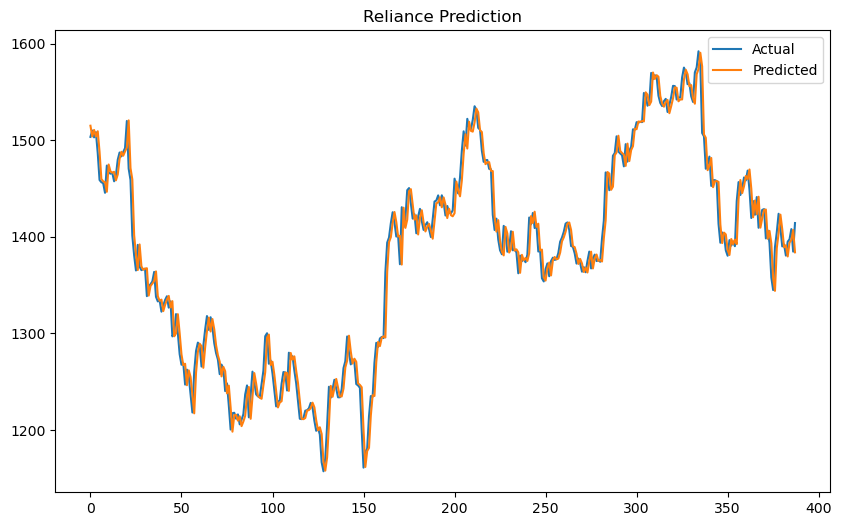

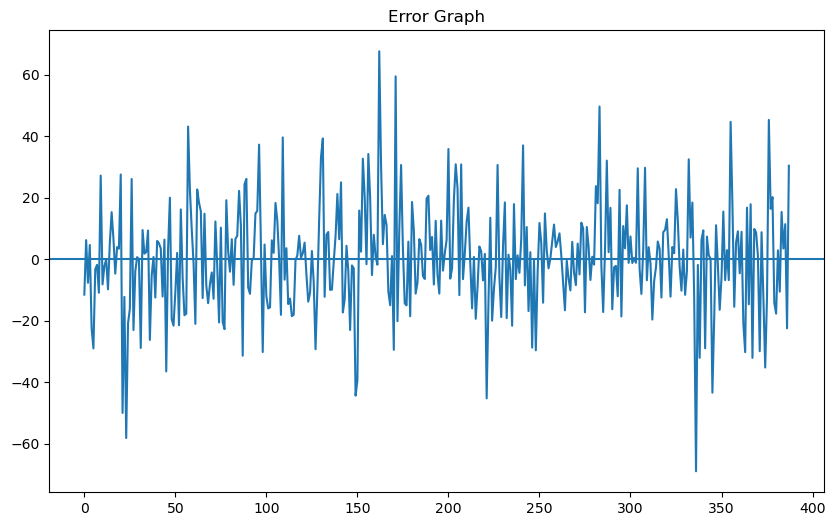

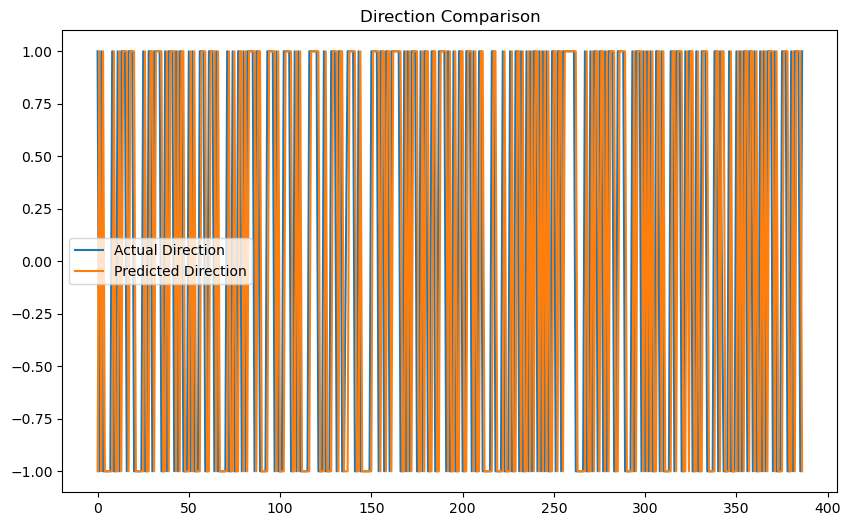

In [1]:
# ================================
# 0. Imports
# ================================
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

import tensorflow as tf
from tensorflow.keras.layers import Layer, LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

from newsapi import NewsApiClient
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


# ================================
# 1. STOCK SELECTION
# ================================
stocks = {
    "Reliance": ("RELIANCE.NS", "Reliance Industries"),
    "TCS": ("TCS.NS", "TCS"),
    "Infosys": ("INFY.NS", "Infosys"),
    "HDFC Bank": ("HDFCBANK.NS", "HDFC Bank"),
    "Bank Nifty": ("^NSEBANK", "Bank Nifty")
}

print("Available Stocks:")
for i, key in enumerate(stocks.keys()):
    print(f"{i+1}. {key}")

choice = int(input("Select stock (1-5): "))
stock_name = list(stocks.keys())[choice-1]
ticker, news_query = stocks[stock_name]

print("\nSelected:", stock_name)


# ================================
# 2. LOAD LIVE DATA
# ================================
df = yf.download(ticker, start="2018-01-01")
df.reset_index(inplace=True)

df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]


# ================================
# 3. INDICATORS
# ================================
df["MA20"] = df["Close"].rolling(20).mean()

delta = df["Close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss
df["RSI"] = 100 - (100/(1+rs))

df["MACD"] = df["Close"].ewm(span=12).mean() - df["Close"].ewm(span=26).mean()

df["Momentum"] = df["Close"] - df["Close"].shift(3)
df["MA5"] = df["Close"].rolling(5).mean()
df["MA50"] = df["Close"].rolling(50).mean()
df["Trend"] = df["MA5"] - df["MA50"]
df["Volatility"] = df["Close"].rolling(5).std()


# ================================
# 4. LIVE NEWS SENTIMENT
# ================================
newsapi = NewsApiClient(api_key="90b7192c1ec04641bad1d548bf2e1232")
analyzer = SentimentIntensityAnalyzer()

end = datetime.today()
start = end - timedelta(days=28)

articles = newsapi.get_everything(
    q=news_query,
    from_param=start.strftime("%Y-%m-%d"),
    to=end.strftime("%Y-%m-%d"),
    language="en",
    page_size=100
)

news_data = []
for a in articles["articles"]:
    news_data.append({
        "Date": a["publishedAt"][:10],
        "headline": a["title"]
    })

news_df = pd.DataFrame(news_data)
news_df["Date"] = pd.to_datetime(news_df["Date"])

news_df["Sentiment"] = news_df["headline"].apply(
    lambda x: analyzer.polarity_scores(x)["compound"]
)

daily_sent = news_df.groupby("Date")["Sentiment"].mean().reset_index()


# ================================
# 5. MERGE
# ================================
df["Date"] = pd.to_datetime(df["Date"])
df = pd.merge(df, daily_sent, on="Date", how="left")

df["Sentiment"].fillna(0, inplace=True)
df["Sent_1"] = df["Sentiment"].shift(1)
df["Sent_2"] = df["Sentiment"].shift(2)


# ================================
# 6. TARGET
# ================================
df["Change"] = df["Close"].diff()
df = df.dropna()


# ================================
# 7. FEATURES
# ================================
features = [
    "Open","High","Low","Volume","MA20","RSI","MACD",
    "Sentiment","Sent_1","Sent_2",
    "Momentum","MA5","MA50","Trend","Volatility"
]

X = df[features]
y = df["Change"]


# ================================
# 8. SCALING
# ================================
X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_scaled = X_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y.values.reshape(-1,1))


# ================================
# 9. SEQUENCES
# ================================
def create_data(X, y, step=45):
    Xs, ys = [], []
    for i in range(step, len(X)):
        Xs.append(X[i-step:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_data(X_scaled, y_scaled, 45)


# ================================
# 10. SPLIT
# ================================
split = int(0.8 * len(X_seq))

X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]


# ================================
# 11. ATTENTION
# ================================
class Attention(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1],1))
        self.b = self.add_weight(shape=(input_shape[1],1))

    def call(self, x):
        e = tf.nn.tanh(tf.matmul(x,self.W)+self.b)
        a = tf.nn.softmax(e, axis=1)
        return tf.reduce_sum(x*a, axis=1)


# ================================
# 12. MODEL
# ================================
inp = Input(shape=(45, X_train.shape[2]))

x = LSTM(128, return_sequences=True)(inp)
x = Dropout(0.2)(x)

x = LSTM(128, return_sequences=True)(x)
x = Dropout(0.2)(x)

x = Attention()(x)
x = Dense(64, activation="relu")(x)

out = Dense(1)(x)

model = Model(inp, out)
model.compile(optimizer="adam", loss="mse")


# ================================
# 13. TRAIN
# ================================
model.fit(
    X_train, y_train,
    validation_data=(X_test,y_test),
    epochs=40,
    batch_size=16,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)












# ================================
# SAVE MODEL + SCALERS
# ================================
import pickle

model.save("model.h5")

pickle.dump(X_scaler, open("X_scaler.pkl", "wb"))
pickle.dump(y_scaler, open("y_scaler.pkl", "wb"))

print("\n✅ Model and scalers saved successfully")






# ================================
# 14. PREDICTION
# ================================
pred = model.predict(X_test)

pred = y_scaler.inverse_transform(pred)
actual = y_scaler.inverse_transform(y_test)


# ================================
# 15. PRICE RECONSTRUCTION
# ================================
actual_prices = []
pred_prices = []

start_idx = len(df) - len(actual)

for i in range(len(actual)):
    prev_price = df["Close"].iloc[start_idx + i - 1]
    actual_prices.append(prev_price + actual[i][0])
    pred_prices.append(prev_price + pred[i][0])


# ================================
# 16. ERROR
# ================================
mae = mean_absolute_error(actual_prices, pred_prices)
error_pct = (mae / np.mean(actual_prices)) * 100

print("\nMAE:", round(mae,2))
print("Error %:", round(error_pct,2), "%")


# ================================
# 17. LAST 5 DAYS OUTPUT
# ================================
print("\n📅 Last 5 Days:\n")

dates = df["Date"].iloc[-len(actual_prices):].reset_index(drop=True)

for d, a, p in zip(dates[-5:], actual_prices[-5:], pred_prices[-5:]):
    print(f"{d.date()} | Actual: ₹{round(a,2)} | Predicted: ₹{round(p,2)}")


# ================================
# 18. BULLISH / BEARISH
# ================================
if pred_prices[-1] > pred_prices[-2]:
    print("\n📈 Market Sentiment: BULLISH")
else:
    print("\n📉 Market Sentiment: BEARISH")


# ================================
# 19. GRAPHS
# ================================
plt.figure(figsize=(10,6))
plt.plot(actual_prices, label="Actual")
plt.plot(pred_prices, label="Predicted")
plt.legend()
plt.title(f"{stock_name} Prediction")
plt.show()

errors = np.array(actual_prices) - np.array(pred_prices)

plt.figure(figsize=(10,6))
plt.plot(errors)
plt.title("Error Graph")
plt.axhline(0)
plt.show()

actual_dir = np.sign(np.diff(actual_prices))
pred_dir = np.sign(np.diff(pred_prices))

plt.figure(figsize=(10,6))
plt.plot(actual_dir, label="Actual Direction")
plt.plot(pred_dir, label="Predicted Direction")
plt.legend()
plt.title("Direction Comparison")
plt.show()

In [2]:
model.save("model.h5")